# Clasificación de Caracteres Japoneses con KMNIST

**KMNIST (Kuzushiji-MNIST)** es un dataset de caracteres del alfabeto japonés *Hiragana* escritos a mano.
Contiene 10 clases que representan los siguientes caracteres:

| Clase | Carácter | Romaji |
|-------|----------|--------|
| 0 | お | o |
| 1 | き | ki |
| 2 | す | su |
| 3 | つ | tsu |
| 4 | な | na |
| 5 | は | ha |
| 6 | ま | ma |
| 7 | や | ya |
| 8 | れ | re |
| 9 | を | wo |

Este dataset posee la misma estructura que el dataset de MNIST (con el cual, se trabajó en la primera práctica), el cual, consiste en 28×28 píxeles, escala de grises y 10 clases.

**Mejoras respecto al modelo original:**
- Función de activación `relu` en lugar de `sigmoid` (evita el problema del gradiente desvanecido)
- Optimizador `Adam` en lugar de `SGD` (convergencia más rápida y estable)
- Capa de `Dropout` para evitar sobreajuste
- El modelo se inicializa una sola vez antes de todo el entrenamiento

In [ ]:
!pip install tensorflow-datasets

In [ ]:
# Librerías necesarias
from tensorflow import keras
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras import models, layers, activations, optimizers, Input
from tensorflow.keras.utils import to_categorical
import numpy as np
import tensorflow_datasets as tfds
from google.colab import drive

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [21]:
# Montaje de mi drive que contiene todo el dataset de KMNIST
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Carga del Dataset KMNIST


In [25]:
import numpy as np

BASE = '/content/drive/MyDrive/TS/KMNINST/'

train        = np.load(BASE + 'kmnist-train-imgs (1).npz')['arr_0']
train_labels = np.load(BASE + 'kmnist-train-labels.npz')['arr_0']
test         = np.load(BASE + 'kmnist-test-imgs.npz')['arr_0']
test_labels  = np.load(BASE + 'kmnist-test-labels.npz')['arr_0']

CLASS_NAMES = ['お (o)', 'き (ki)', 'す (su)', 'つ (tsu)', 'な (na)',
               'は (ha)', 'ま (ma)', 'や (ya)', 'れ (re)', 'を (wo)']

print("Train:", train.shape)
print("Test: ", test.shape)

Train: (60000, 28, 28)
Test:  (10000, 28, 28)


**Explicación del output:** Al cargar KMNIST se obtienen las mismas dimensiones que MNIST: 60,000 imágenes de entrenamiento y 10,000 de prueba, cada una de 28×28 píxeles en escala de grises. La diferencia está en el contenido: en lugar de dígitos, cada imagen representa un carácter del Hiragana japonés.

## 2. Visualización de los datos

Las 10 clases de KMNIST corresponden a los caracteres: お き す つ な は ま や れ を

/tmp/ipykernel_3386/1911207621.py:16: UserWarning: Glyph 12362 (\N{HIRAGANA LETTER O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/1911207621.py:16: UserWarning: Glyph 12365 (\N{HIRAGANA LETTER KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/1911207621.py:16: UserWarning: Glyph 12377 (\N{HIRAGANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/1911207621.py:16: UserWarning: Glyph 12388 (\N{HIRAGANA LETTER TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/1911207621.py:16: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/1911207621.py:16: UserWarning: Glyph 12399 (\N{HIRAGANA LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/1911207621.py:16: UserWarning: Glyph 12414 (\N{HIRAGANA LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


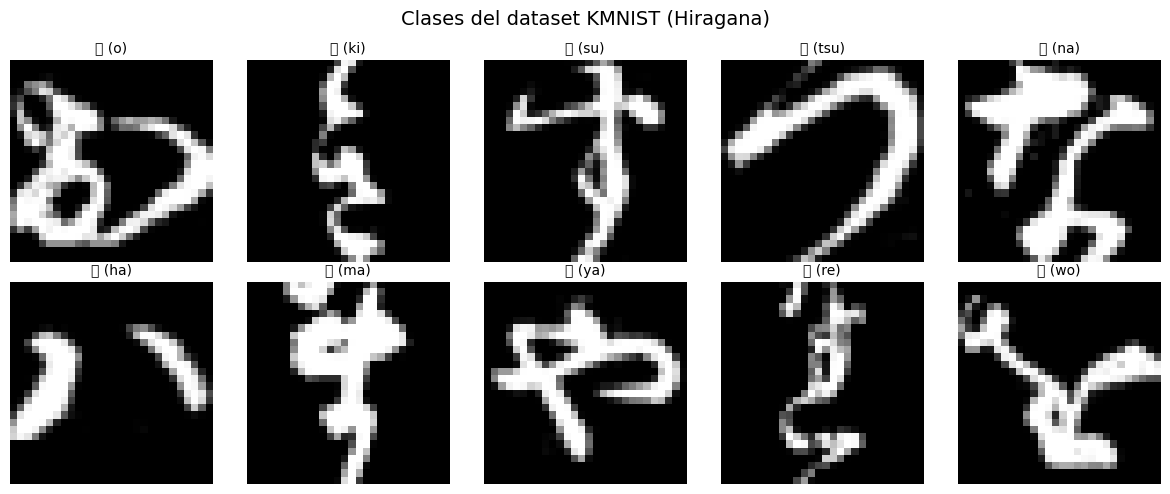

In [26]:
# Nombres de las 10 clases en Hiragana y Romaji
CLASS_NAMES = ['お (o)', 'き (ki)', 'す (su)', 'つ (tsu)', 'な (na)',
               'は (ha)', 'ま (ma)', 'や (ya)', 'れ (re)', 'を (wo)']

# Mostrar una muestra de cada clase
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Clases del dataset KMNIST (Hiragana)', fontsize=14)

for cls in range(10):
    idx = np.where(train_labels == cls)[0][0]  # primera imagen de cada clase
    ax = axes[cls // 5][cls % 5]
    ax.imshow(train[idx], cmap='gray')
    ax.set_title(CLASS_NAMES[cls], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

**Explicación del output:** Se visualiza un ejemplo de cada uno de los 10 caracteres Hiragana que el modelo deberá aprender a distinguir. A diferencia de los dígitos del 0 al 9, estos trazos son más complejos y visualmente similares entre sí, lo que hace al dataset más desafiante.

/tmp/ipykernel_3386/3463522651.py:10: UserWarning: Glyph 12428 (\N{HIRAGANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/3463522651.py:10: UserWarning: Glyph 12420 (\N{HIRAGANA LETTER YA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/3463522651.py:10: UserWarning: Glyph 12362 (\N{HIRAGANA LETTER O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/3463522651.py:10: UserWarning: Glyph 12365 (\N{HIRAGANA LETTER KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/3463522651.py:10: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/3463522651.py:10: UserWarning: Glyph 12377 (\N{HIRAGANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/3463522651.py:10: UserWarning: Glyph 12399 (\N{HIRAGANA LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


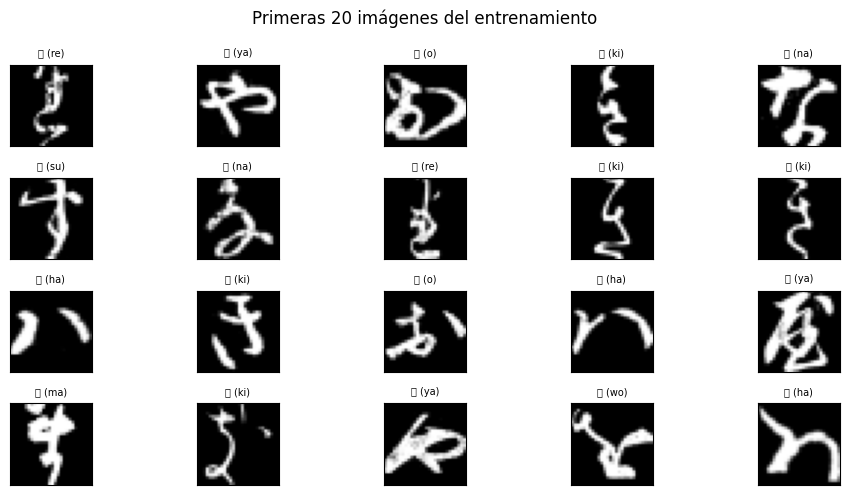

In [27]:
# Mostrar las primeras 20 imágenes del set de entrenamiento
fig = plt.figure(figsize=(10, 5))
for i in range(20):
    ax = fig.add_subplot(4, 5, i + 1)
    plt.imshow(train[i], cmap='gray')
    plt.title(CLASS_NAMES[train_labels[i]], fontsize=7)
    plt.xticks([])
    plt.yticks([])
plt.suptitle('Primeras 20 imágenes del entrenamiento', fontsize=12)
plt.tight_layout()
plt.show()

**Explicación del output:** Se generó una cuadrícula con las primeras 20 imágenes del set de entrenamiento. Cada imagen muestra un carácter Hiragana con su nombre en romaji. Se puede observar la variabilidad en la escritura a mano de cada persona.

## 3. División y preprocesamiento de los datos

In [28]:
# División en entrenamiento y validación (90% / 10%)
train, val, train_labels, val_labels = train_test_split(
    train, train_labels, test_size=0.1, random_state=42
)

print("Train:", train.shape)
print("Val:  ", val.shape)
print("Test: ", test.shape)

Train: (54000, 28, 28)
Val:   (6000, 28, 28)
Test:  (10000, 28, 28)


In [29]:
# Aplanamiento: de (28,28) a vector de 784 valores
train = train.reshape((54000, 28 * 28)).astype('float32') / 255
val   = val.reshape((6000, 28 * 28)).astype('float32') / 255
test  = test.reshape((10000, 28 * 28)).astype('float32') / 255

# Conversión de etiquetas a formato one-hot
train_labels_cat = to_categorical(train_labels)
val_labels_cat   = to_categorical(val_labels)

print("Shape etiquetas entrenamiento:", train_labels_cat.shape)
print("Ejemplo de etiqueta one-hot:  ", train_labels_cat[0])

Shape etiquetas entrenamiento: (54000, 10)
Ejemplo de etiqueta one-hot:   [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


**Explicación del output:**
Confirma que las 54,000 imágenes de entrenamiento tienen su etiqueta convertida
al formato **one-hot**: en lugar de guardar un número del 0 al 9, cada etiqueta
es ahora un vector de 10 posiciones.

### Ejemplo de etiqueta one-hot: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
Este vector representa el carácter **を (wo)**, que corresponde a la clase 9
(la última posición vale `1` y todas las demás valen `0`).

| Posición | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|----------|---|---|---|---|---|---|---|---|---|---|
| Clase    | お| き| す| つ| な| は| ま| や| れ| を|
| Vector   | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1 |

### ¿Por qué one-hot?
El modelo no puede trabajar directamente con números enteros como etiquetas
(0, 1, 2...) porque implicaría una relación de orden entre clases que no existe
— el carácter `き` no es "mayor" que `お`. El formato one-hot representa cada
clase como una dirección independiente en el espacio, lo que permite que
`softmax` en la capa de salida calcule una probabilidad para cada clase por separado.

### Normalización de imágenes
Cada píxel originalmente va de **0** (negro) a **255** (blanco) en formato entero.
Al dividir entre 255, los valores quedan entre **0.0 y 1.0**, lo que estabiliza
el entrenamiento y evita que gradientes muy grandes desestabilicen los pesos
de la red.

## 4. Visualización de funciones de activación

Comparamos las funciones de activación disponibles para entender por qué `relu` es mejor que `sigmoid` para este tipo de red.

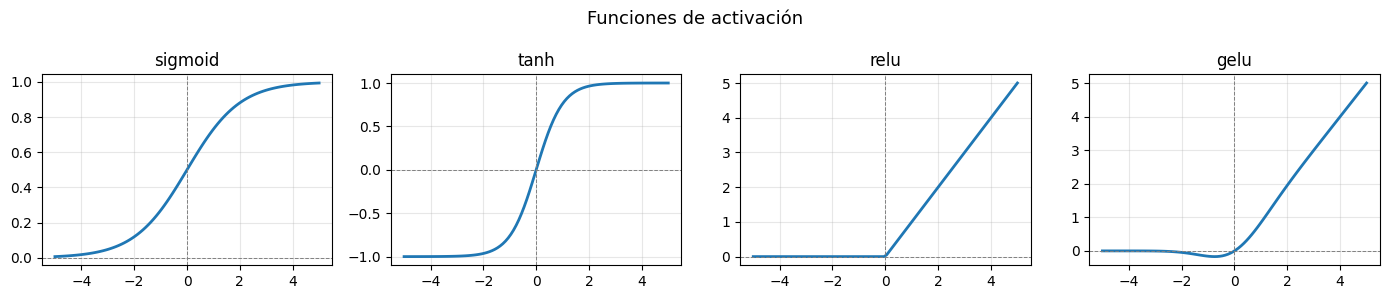

In [30]:
acts      = [activations.sigmoid, activations.tanh, activations.relu, activations.gelu]
act_names = ['sigmoid', 'tanh', 'relu', 'gelu']

def plot_act(acts, names):
    x = np.linspace(-5, 5, 100)
    fig, axs = plt.subplots(1, 4, figsize=(14, 3))
    for i, (act, nm) in enumerate(zip(acts, names)):
        y = act(x)
        axs[i].plot(x, y, linewidth=2)
        axs[i].set_title(nm, fontsize=12)
        axs[i].axhline(0, color='gray', linestyle='--', linewidth=0.7)
        axs[i].axvline(0, color='gray', linestyle='--', linewidth=0.7)
        axs[i].grid(True, alpha=0.3)
    plt.suptitle('Funciones de activación', fontsize=13)
    plt.tight_layout()
    plt.show()

plot_act(acts, act_names)

**Explicación del output:** Las cuatro gráficas muestran cómo transforma cada función el valor de entrada de una neurona. `sigmoid` y `tanh` saturan (aplanan) sus valores en los extremos, lo que provoca el problema del gradiente desvanecido: la red deja de aprender. `relu` y `gelu` no tienen este problema porque permiten que los valores positivos pasen sin saturarse, haciendo el entrenamiento más estable y rápido.

## 5. Arquitectura de la red neuronal
Usamos la misma estructura que el modelo original pero con las siguientes mejoras clave:

### `relu` en lugar de `sigmoid`
En el modelo original, `sigmoid` causaba el problema del **gradiente desvanecido**:
al propagar el error hacia atrás, los gradientes se volvían tan pequeños que las
neuronas dejaban de actualizarse y el modelo colapsaba (cayó al 11% de exactitud).
`relu` evita esto porque no satura los valores positivos, permitiendo que el
aprendizaje fluya correctamente a través de todas las capas.

### `Dropout` para evitar sobreajuste
El modelo original no tenía ningún mecanismo de regularización, lo que lo hacía
propenso a **memorizar** los datos de entrenamiento en lugar de aprender patrones
generales. `Dropout(0.3)` apaga aleatoriamente el 30% de las neuronas en cada
paso, forzando a la red a no depender de neuronas específicas y mejorando su
capacidad de generalización.

### `Adam` como optimizador
El modelo original usaba `SGD` con `learning_rate=0.01`, que avanza siempre con
el mismo tamaño de paso sin importar el estado del entrenamiento. `Adam` ajusta
automáticamente la tasa de aprendizaje para cada parámetro individualmente,
lo que resulta en una convergencia más rápida y estable, especialmente útil
cuando los datos son complejos como los trazos del Hiragana.

In [31]:
# Definición del modelo
network = models.Sequential(name='KMNIST_Classifier')

network.add(Input(shape=(784,)))

# Capa oculta 1: 512 neuronas con relu
# relu evita el gradiente desvanecido que causaba problemas con sigmoid
network.add(layers.Dense(512, activation='relu'))

# Dropout: apaga el 30% de neuronas aleatoriamente durante el entrenamiento
# Esto fuerza a la red a no depender de neuronas específicas → mejor generalización
network.add(layers.Dropout(0.3))

# Capa oculta 2: 256 neuronas con relu
network.add(layers.Dense(256, activation='relu'))
network.add(layers.Dropout(0.2))

# Capa de salida: 10 neuronas (una por carácter), softmax convierte a probabilidades
network.add(layers.Dense(10, activation='softmax'))

network.summary()

Model: "KMNIST_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

**Explicación del output:** El resumen muestra todas las capas del modelo y el número de parámetros que deberá aprender. Se añadió una segunda capa oculta de 256 neuronas y capas de Dropout, lo que aumenta la capacidad de la red para aprender patrones más complejos como los trazos del Hiragana.

In [32]:
# Compilación del modelo con Adam (mejor que SGD para este tipo de tareas)
# Adam ajusta automáticamente la tasa de aprendizaje por cada parámetro
network.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 6. Entrenamiento del modelo

In [33]:
# EarlyStopping: detiene el entrenamiento si el modelo deja de mejorar
# Evita el sobreajuste y el colapso que ocurrió en el modelo original
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,           # espera 5 épocas sin mejora antes de detenerse
    restore_best_weights=True  # recupera los mejores pesos encontrados
)

history = network.fit(
    train,
    train_labels_cat,
    validation_data=(val, val_labels_cat),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8581 - loss: 0.4585 - val_accuracy: 0.9283 - val_loss: 0.2334
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9345 - loss: 0.2121 - val_accuracy: 0.9497 - val_loss: 0.1704
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9526 - loss: 0.1533 - val_accuracy: 0.9580 - val_loss: 0.1453
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9633 - loss: 0.1198 - val_accuracy: 0.9595 - val_loss: 0.1399
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9697 - loss: 0.0969 - val_accuracy: 0.9647 - val_loss: 0.1278
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9734 - loss: 0.0841 - val_accuracy: 0.9600 - val_loss: 0.1450
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.9776 - loss: 0.0694 - val_accuracy: 0.9647 - val_loss: 0.1341
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9793 - loss: 0.0638 - val_ac

**Explicación del output:** Durante el entrenamiento se reporta en tiempo real la exactitud y pérdida en cada época, tanto para el set de entrenamiento como para el de validación. El callback de EarlyStopping detendrá el proceso automáticamente si detecta que el modelo dejó de mejorar, evitando así el colapso que ocurrió en el modelo base.

## 7. Visualización del aprendizaje

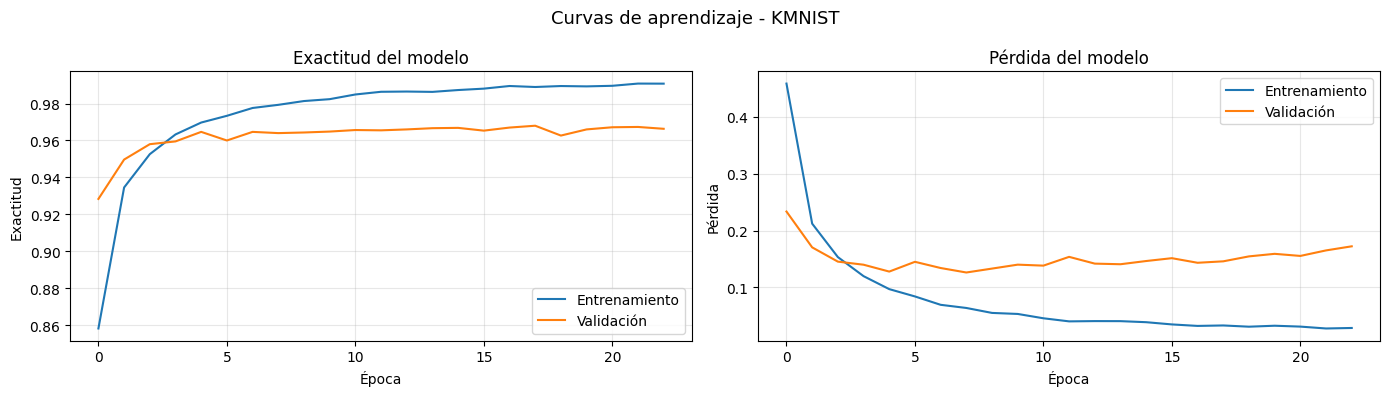

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico de exactitud
ax1.plot(history.history['accuracy'], label='Entrenamiento')
ax1.plot(history.history['val_accuracy'], label='Validación')
ax1.set_title('Exactitud del modelo')
ax1.set_xlabel('Época')
ax1.set_ylabel('Exactitud')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico de pérdida
ax2.plot(history.history['loss'], label='Entrenamiento')
ax2.plot(history.history['val_loss'], label='Validación')
ax2.set_title('Pérdida del modelo')
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizaje - KMNIST', fontsize=13)
plt.tight_layout()
plt.show()

**Explicación del output:** La curva de entrenamiento sube de forma agresiva desde el **86%** en la época 0
hasta estabilizarse cerca del **99%** al final. La curva de validación también
sube rápido, arrancando desde el **92%** y estabilizándose alrededor del **96-97%**.

Ambas curvas caen drásticamente en las primeras 5 épocas, lo que indica que
el modelo aprendió los patrones más importantes al inicio del entrenamiento.
La pérdida de entrenamiento sigue bajando hasta ~**0.05**, mientras que la
de validación se estabiliza en ~**0.15**.

Explicando de forma mas detallada el presente diagrama:
-  **Buen aprendizaje**: ambas curvas de exactitud suben consistentemente
-  **Sin colapso**: no hay caída brusca como ocurrió en el modelo original con sigmoid, ya que provocaba errores esa función de activación.
-  **Leve sobreajuste**: la brecha entre entrenamiento (99%) y validación (96%)
  indica que el modelo memoriza un poco más de lo que generaliza
-  **EarlyStopping funcionó**: el entrenamiento se detuvo en la época ~23 antes
  de que el sobreajuste empeorara


## 8. Evaluación final

In [35]:
# Predicciones sobre el set de prueba
pred = network.predict(test)
pred_classes = np.argmax(pred, axis=1)

print("Shape de predicciones:", pred.shape)

# Reporte detallado por clase
print("\n--- Reporte de Clasificación ---")
print(classification_report(test_labels, pred_classes, target_names=CLASS_NAMES))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Shape de predicciones: (10000, 10)

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

       お (o)       0.96      0.93      0.94      1000
      き (ki)       0.92      0.90      0.91      1000
      す (su)       0.88      0.88      0.88      1000
     つ (tsu)       0.91      0.96      0.93      1000
      な (na)       0.88      0.92      0.89      1000
      は (ha)       0.94      0.92      0.93      1000
      ま (ma)       0.84      0.95      0.89      1000
      や (ya)       0.98      0.86      0.91      1000
      れ (re)       0.90      0.93      0.92      1000
      を (wo)       0.96      0.89      0.93      1000

    accuracy                           0.91     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.91      0.91     10000



**Explicación del output:** El reporte detalla la precisión y recuperación para cada uno de los 10 caracteres Hiragana. Caracteres con trazos más únicos (como や o を) suelen tener mejor precisión, mientras que los que se parecen visualmente (como き y れ) pueden confundirse con más frecuencia.

## 9. Visualización de resultados

/tmp/ipykernel_3386/3187366910.py:25: UserWarning: Glyph 12377 (\N{HIRAGANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/3187366910.py:25: UserWarning: Glyph 12362 (\N{HIRAGANA LETTER O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/3187366910.py:25: UserWarning: Glyph 12365 (\N{HIRAGANA LETTER KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/3187366910.py:25: UserWarning: Glyph 12388 (\N{HIRAGANA LETTER TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/3187366910.py:25: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/3187366910.py:25: UserWarning: Glyph 12399 (\N{HIRAGANA LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3386/3187366910.py:25: UserWarning: Glyph 12414 (\N{HIRAGANA LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


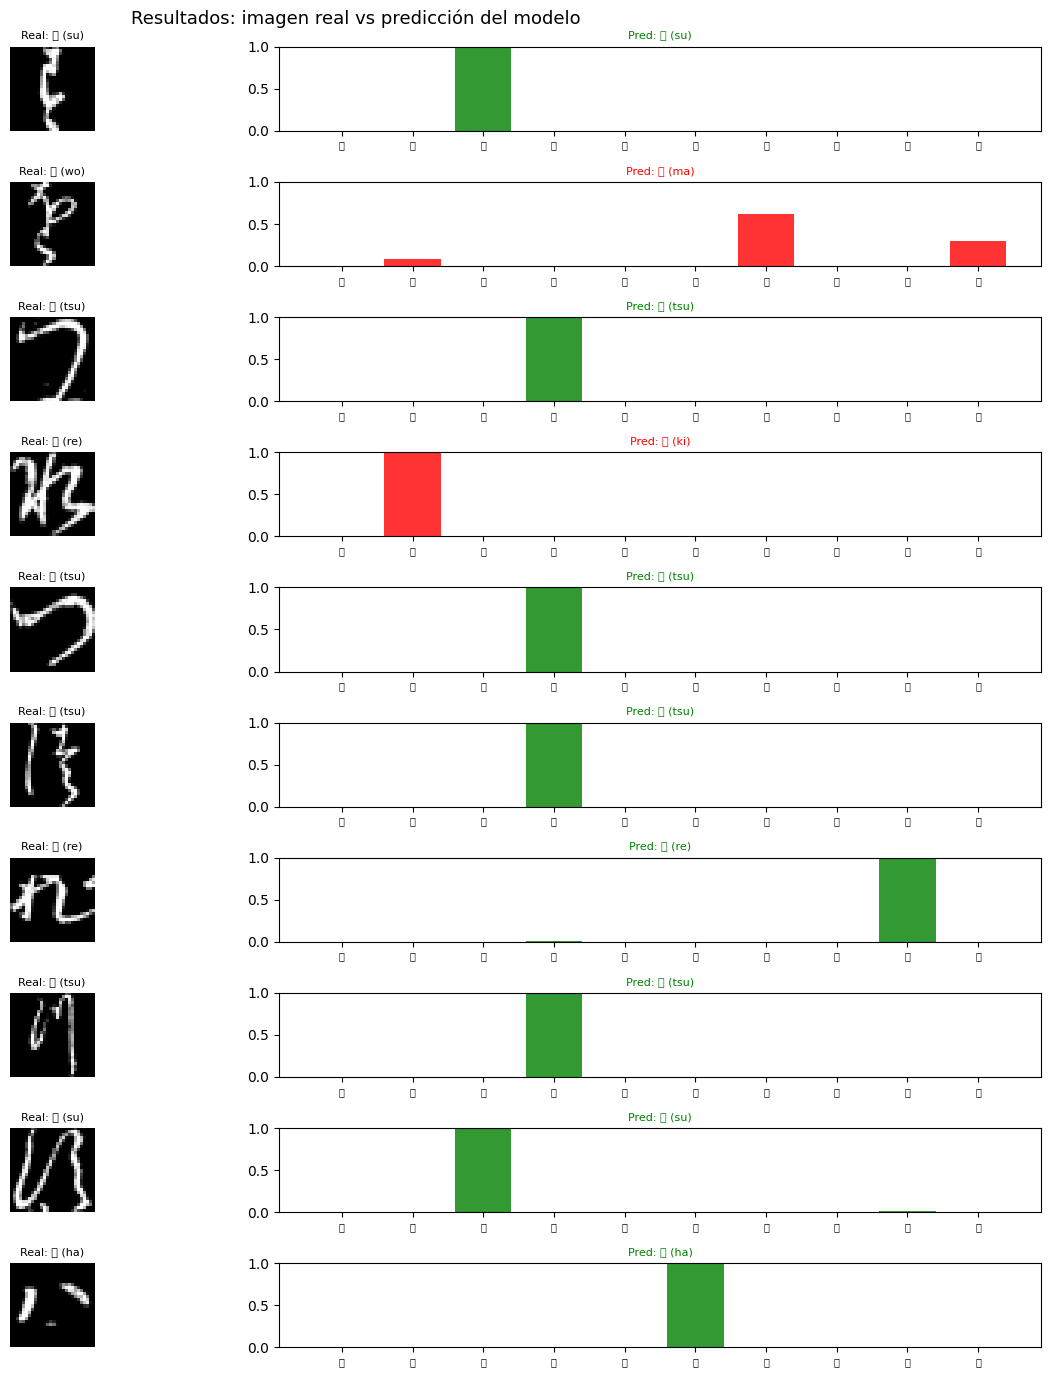

In [36]:
# Comparación visual: imagen real vs predicción del modelo
fig = plt.figure(figsize=(14, 14))
fig.suptitle('Resultados: imagen real vs predicción del modelo', fontsize=13)

for i in range(10):
    img = test[i].reshape(28, 28)
    p = pred[i]
    acierto = pred_classes[i] == test_labels[i]
    color = 'green' if acierto else 'red'

    # Imagen a la izquierda
    ax_img = fig.add_subplot(10, 2, 2 * i + 1)
    ax_img.imshow(img, cmap='gray')
    ax_img.set_title(f'Real: {CLASS_NAMES[test_labels[i]]}', fontsize=8)
    ax_img.axis('off')

    # Barras de probabilidad a la derecha
    ax_bar = fig.add_subplot(10, 2, 2 * i + 2)
    ax_bar.bar(range(10), p, color=color, alpha=0.8)
    ax_bar.set_xticks(range(10))
    ax_bar.set_xticklabels([n.split()[0] for n in CLASS_NAMES], fontsize=7)
    ax_bar.set_ylim(0, 1)
    ax_bar.set_title(f'Pred: {CLASS_NAMES[pred_classes[i]]}', fontsize=8, color=color)

plt.tight_layout()
plt.show()

**Explicación del output:** Cada fila muestra una imagen del set de prueba junto a las probabilidades asignadas por el modelo para cada clase. Las barras verdes indican que el modelo acertó: la barra más alta coincide con el carácter real. Las barras rojas indican un error de clasificación, donde la barra más alta apunta a un carácter incorrecto.

In [37]:
# Resumen final de exactitud
loss, accuracy = network.evaluate(test, to_categorical(test_labels), verbose=0)
print(f'Pérdida final en test:    {loss:.4f}')
print(f'Exactitud final en test:  {accuracy * 100:.2f}%')

Pérdida final en test:    0.4328
Exactitud final en test:  91.35%


**Explicación del output:** Se muestra el rendimiento final del modelo sobre datos que nunca vio durante el entrenamiento. Destacando que el modelo cuenta con un accuracy del **91.35%** y una perdida de aprendizaje del **0.4328%**.

In [38]:
network.save('/content/drive/MyDrive/TS/kmnist_model.keras')
print("✓ Modelo guardado")

✓ Modelo guardado
